        date  precipitation
0 2024-01-01       0.000000
1 2024-01-02       0.037781
2 2024-01-03       0.166000
3 2024-01-04       1.718071
4 2024-01-05       0.217154


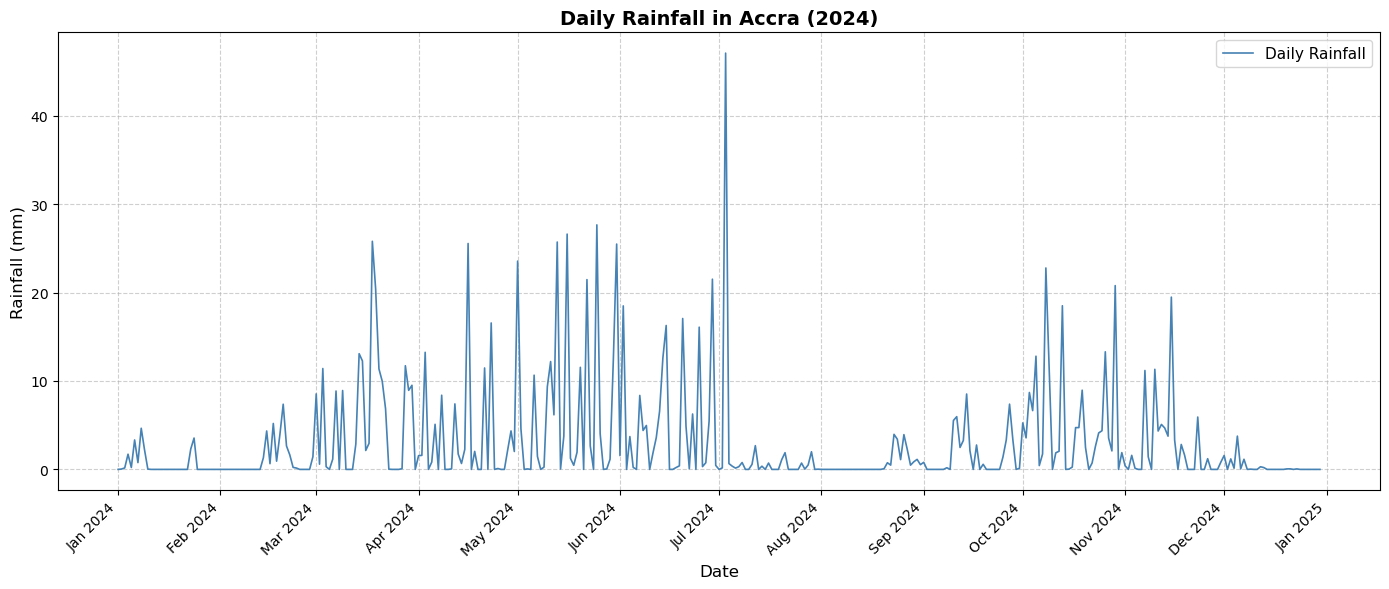

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load rainfall data
df = pd.read_csv("../data/processed/chirps_accra_2024.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Preview data
print(df.head())

# Plot rainfall time series
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df["date"],
    df["precipitation"],
    color="steelblue",
    linewidth=1.2,
    linestyle="-",
    label="Daily Rainfall",
)

# Format x-axis with cleaner date tick labels
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Labels and title
ax.set_title("Daily Rainfall in Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)

# Prevent label clipping
plt.tight_layout()

# Save to file before showing
plt.savefig("../data/processed/accra_rainfall_2024.png", dpi=150, bbox_inches="tight")

plt.show()

In [6]:
#Monthly Rainfall Analysis

     month  total_precipitation
2024-01-31            18.997865
2024-02-29            29.851994
2024-03-31           177.810777
2024-04-30           107.175551
2024-05-31           234.687048
2024-06-30           156.186236
2024-07-31            60.118316
2024-08-31            19.042186
2024-09-30            47.799846
2024-10-31           170.372392
2024-11-30            79.127311
2024-12-31             8.575480


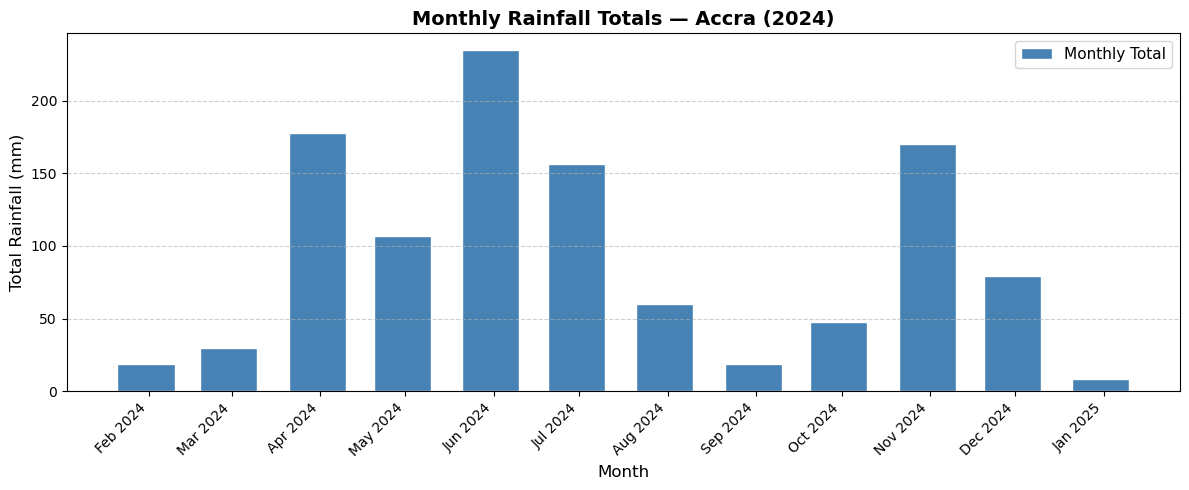

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create monthly totals
monthly_rainfall = (
    df
    .set_index("date")
    .resample("ME")          # "ME" = Month End (updated alias in pandas 2.2+)
    ["precipitation"]
    .sum()
    .reset_index()
)
monthly_rainfall.columns = ["month", "total_precipitation"]

# Display results
print(monthly_rainfall.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    monthly_rainfall["month"],
    monthly_rainfall["total_precipitation"],
    color="steelblue",
    edgecolor="white",
    width=20,
    label="Monthly Total",
)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Monthly Rainfall Totals — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../data/processed/accra_monthly_rainfall_2024.png", dpi=150, bbox_inches="tight")
plt.show()

            precipitation   roll_7d  roll_30d  cumulative
date                                                     
2024-01-01       0.000000  0.000000  0.000000    0.000000
2024-01-02       0.037781  0.018891  0.018891    0.037781
2024-01-03       0.166000  0.067927  0.067927    0.203781
2024-01-04       1.718071  0.480463  0.480463    1.921852
2024-01-05       0.217154  0.427801  0.427801    2.139006
2024-01-06       3.331029  0.911673  0.911673    5.470036
2024-01-07       0.769166  0.891315  0.891315    6.239202
2024-01-08       4.654909  1.556302  1.361764   10.894111
2024-01-09       2.214521  1.867264  1.456515   13.108631
2024-01-10       0.034213  1.848438  1.314284   13.142845


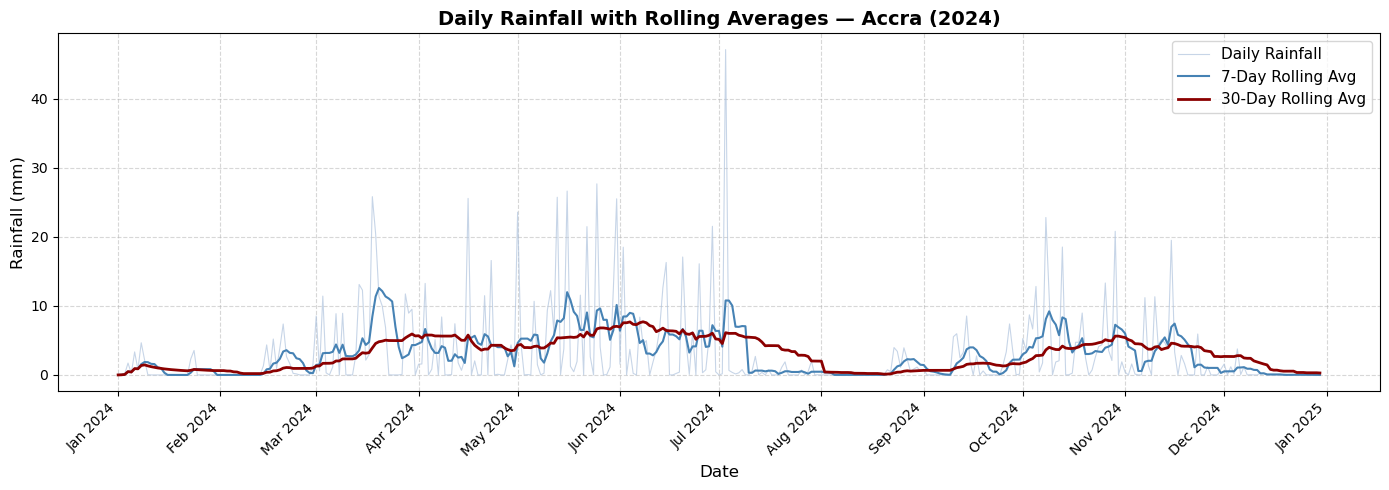

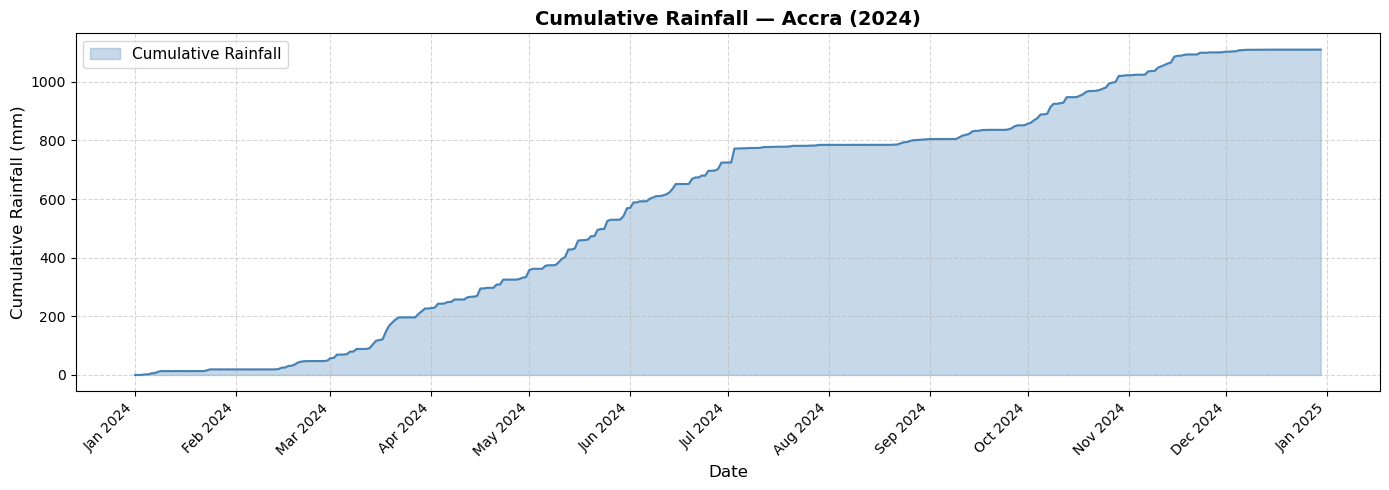

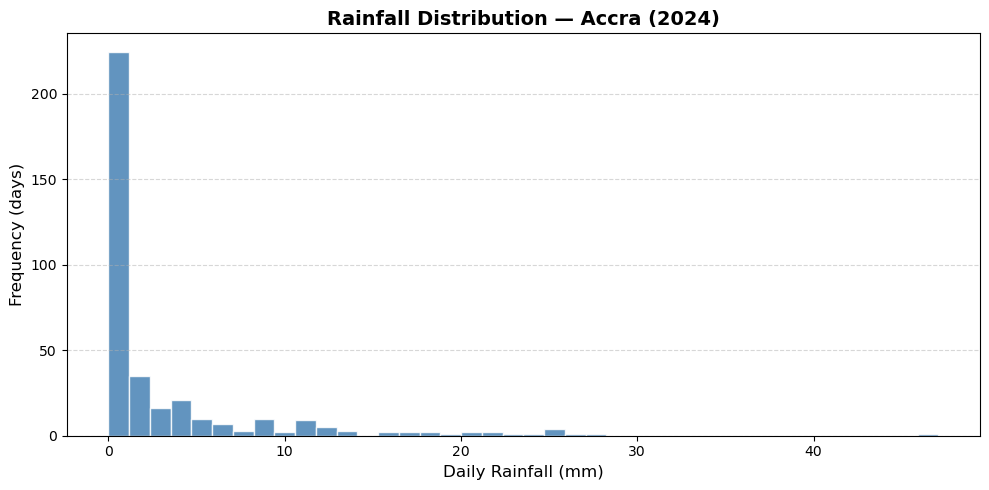

In [8]:
##Rolling Averages, Cumulative Rainfall & Histogram
# ── Feature Engineering ──────────────────────────────────────────────
df_fe = df.copy().set_index("date").sort_index()

# 7-day and 30-day rolling averages
df_fe["roll_7d"]  = df_fe["precipitation"].rolling(window=7,  min_periods=1).mean()
df_fe["roll_30d"] = df_fe["precipitation"].rolling(window=30, min_periods=1).mean()

# Cumulative rainfall for the year
df_fe["cumulative"] = df_fe["precipitation"].cumsum()

print(df_fe.head(10).to_string())

# ── Plot 1: Rolling Averages ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_fe.index, df_fe["precipitation"],
        color="lightsteelblue", linewidth=0.8, label="Daily Rainfall", alpha=0.7)
ax.plot(df_fe.index, df_fe["roll_7d"],
        color="steelblue", linewidth=1.5, label="7-Day Rolling Avg")
ax.plot(df_fe.index, df_fe["roll_30d"],
        color="darkred", linewidth=2.0, label="30-Day Rolling Avg")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Daily Rainfall with Rolling Averages — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_rolling_avg_2024.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Cumulative Rainfall ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_fe.index, df_fe["cumulative"],
                color="steelblue", alpha=0.3, label="Cumulative Rainfall")
ax.plot(df_fe.index, df_fe["cumulative"],
        color="steelblue", linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Cumulative Rainfall — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_cumulative_rainfall_2024.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Rainfall Histogram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_fe["precipitation"], bins=40,
        color="steelblue", edgecolor="white", alpha=0.85)

ax.set_title("Rainfall Distribution — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Rainfall (mm)", fontsize=12)
ax.set_ylabel("Frequency (days)", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_rainfall_histogram_2024.png", dpi=150, bbox_inches="tight")
plt.show()


🔴 Extreme rainfall days (≥30 mm): 1
            precipitation
date                     
2024-07-03      47.084717

🟠 High rainfall days (≥15 mm): 19
            precipitation
date                     
2024-03-18      25.803489
2024-03-19      20.400253
2024-04-16      25.549006
2024-04-23      16.565033
2024-05-01      23.557323
2024-05-13      25.715242
2024-05-16      26.611757
2024-05-22      21.465099
2024-05-25      27.655854
2024-05-31      25.490120
2024-06-02      18.490554
2024-06-15      16.278101
2024-06-20      17.069104
2024-06-25      16.089372
2024-06-29      21.513242
2024-10-08      22.786453
2024-10-13      18.512692
2024-10-29      20.786732
2024-11-15      19.487582


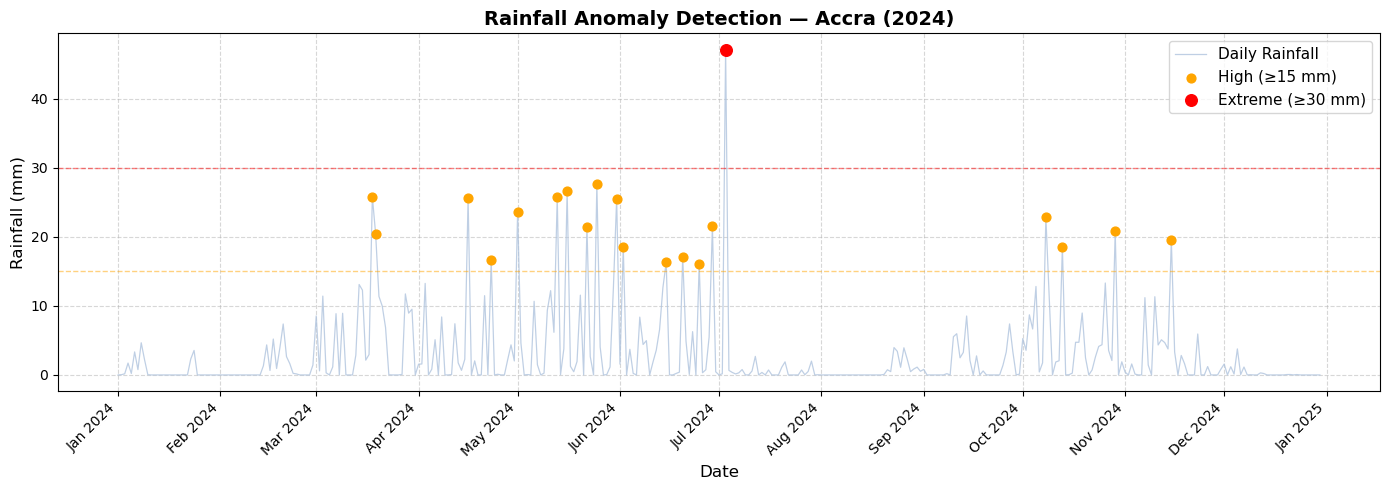

In [9]:
#Anomaly Detection & Extreme Rainfall Alerts
# ── Anomaly Detection ─────────────────────────────────────────────────
EXTREME_THRESHOLD_MM = 30      # >30 mm/day = extreme rainfall event
HIGH_THRESHOLD_MM    = 15      # >15 mm/day = high rainfall

df_fe["anomaly_extreme"] = df_fe["precipitation"] >= EXTREME_THRESHOLD_MM
df_fe["anomaly_high"]    = (df_fe["precipitation"] >= HIGH_THRESHOLD_MM) & \
                            (df_fe["precipitation"] <  EXTREME_THRESHOLD_MM)

extreme_days = df_fe[df_fe["anomaly_extreme"]]
high_days    = df_fe[df_fe["anomaly_high"]]

print(f"\n🔴 Extreme rainfall days (≥{EXTREME_THRESHOLD_MM} mm): {len(extreme_days)}")
print(extreme_days[["precipitation"]].to_string())

print(f"\n🟠 High rainfall days (≥{HIGH_THRESHOLD_MM} mm): {len(high_days)}")
print(high_days[["precipitation"]].to_string())

# ── Plot: Anomaly Overlay ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_fe.index, df_fe["precipitation"],
        color="lightsteelblue", linewidth=0.9, label="Daily Rainfall", alpha=0.8)

ax.scatter(high_days.index,    high_days["precipitation"],
           color="orange",  s=40, zorder=5, label=f"High (≥{HIGH_THRESHOLD_MM} mm)")
ax.scatter(extreme_days.index, extreme_days["precipitation"],
           color="red",     s=70, zorder=6, label=f"Extreme (≥{EXTREME_THRESHOLD_MM} mm)")

ax.axhline(y=EXTREME_THRESHOLD_MM, color="red",    linestyle="--", linewidth=1.0, alpha=0.5)
ax.axhline(y=HIGH_THRESHOLD_MM,    color="orange",  linestyle="--", linewidth=1.0, alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Rainfall Anomaly Detection — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_anomaly_detection_2024.png", dpi=150, bbox_inches="tight")
plt.show()

── Rainfall Classification Preview ──
      date  precipitation rainfall_class
2024-01-01       0.000000            Dry
2024-01-02       0.037781          Light
2024-01-03       0.166000          Light
2024-01-04       1.718071          Light
2024-01-05       0.217154          Light
2024-01-06       3.331029          Light
2024-01-07       0.769166          Light
2024-01-08       4.654909          Light
2024-01-09       2.214521          Light
2024-01-10       0.034213          Light
2024-01-11       0.000000            Dry
2024-01-12       0.000000            Dry
2024-01-13       0.000000            Dry
2024-01-14       0.000000            Dry
2024-01-15       0.000000            Dry
2024-01-16       0.000000            Dry
2024-01-17       0.000000            Dry
2024-01-18       0.000000            Dry
2024-01-19       0.000000            Dry
2024-01-20       0.000000            Dry

── Rainfall Class Frequencies ──
rainfall_class
Light       152
Dry         148
Moderate     45
High

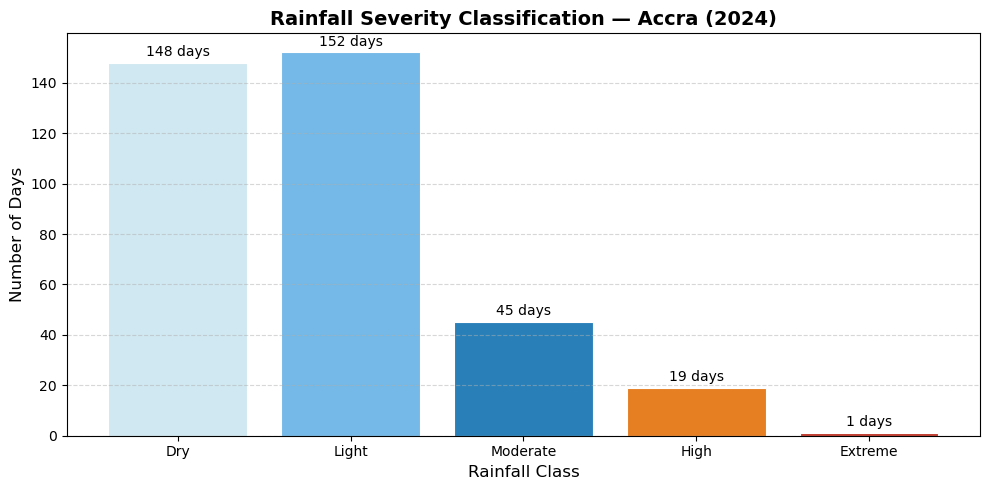

In [10]:
#Rainfall Severity Classification
import pandas as pd
import matplotlib.pyplot as plt

# ── Rainfall Classification Function ─────────────────────────────────
def classify_rainfall(value):
    if value >= 30:
        return "Extreme"
    elif value >= 15:
        return "High"
    elif value >= 5:
        return "Moderate"
    elif value > 0:
        return "Light"
    return "Dry"

# Apply classification
df["rainfall_class"] = df["precipitation"].apply(classify_rainfall)

# Preview
print("── Rainfall Classification Preview ──")
print(df[["date", "precipitation", "rainfall_class"]].head(20).to_string(index=False))

# ── Class Frequencies ─────────────────────────────────────────────────
class_counts = df["rainfall_class"].value_counts()
class_order  = ["Dry", "Light", "Moderate", "High", "Extreme"]
class_colors = {
    "Dry":      "#d0e8f1",
    "Light":    "#74b9e7",
    "Moderate": "#2980b9",
    "High":     "#e67e22",
    "Extreme":  "#c0392b",
}

print("\n── Rainfall Class Frequencies ──")
print(class_counts.to_string())

# ── Plot: Class Frequency Bar Chart ──────────────────────────────────
ordered_counts = class_counts.reindex(class_order).fillna(0)
colors         = [class_colors[c] for c in class_order]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    ordered_counts.index,
    ordered_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

# Annotate bar values
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{int(bar.get_height())} days",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Rainfall Severity Classification — Accra (2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rainfall Class", fontsize=12)
ax.set_ylabel("Number of Days", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/accra_rainfall_classes_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()


🔵 Statistical anomaly days (z > 2.0): 31
🌧️  Wet spell days (≥3 consecutive wet days): 89


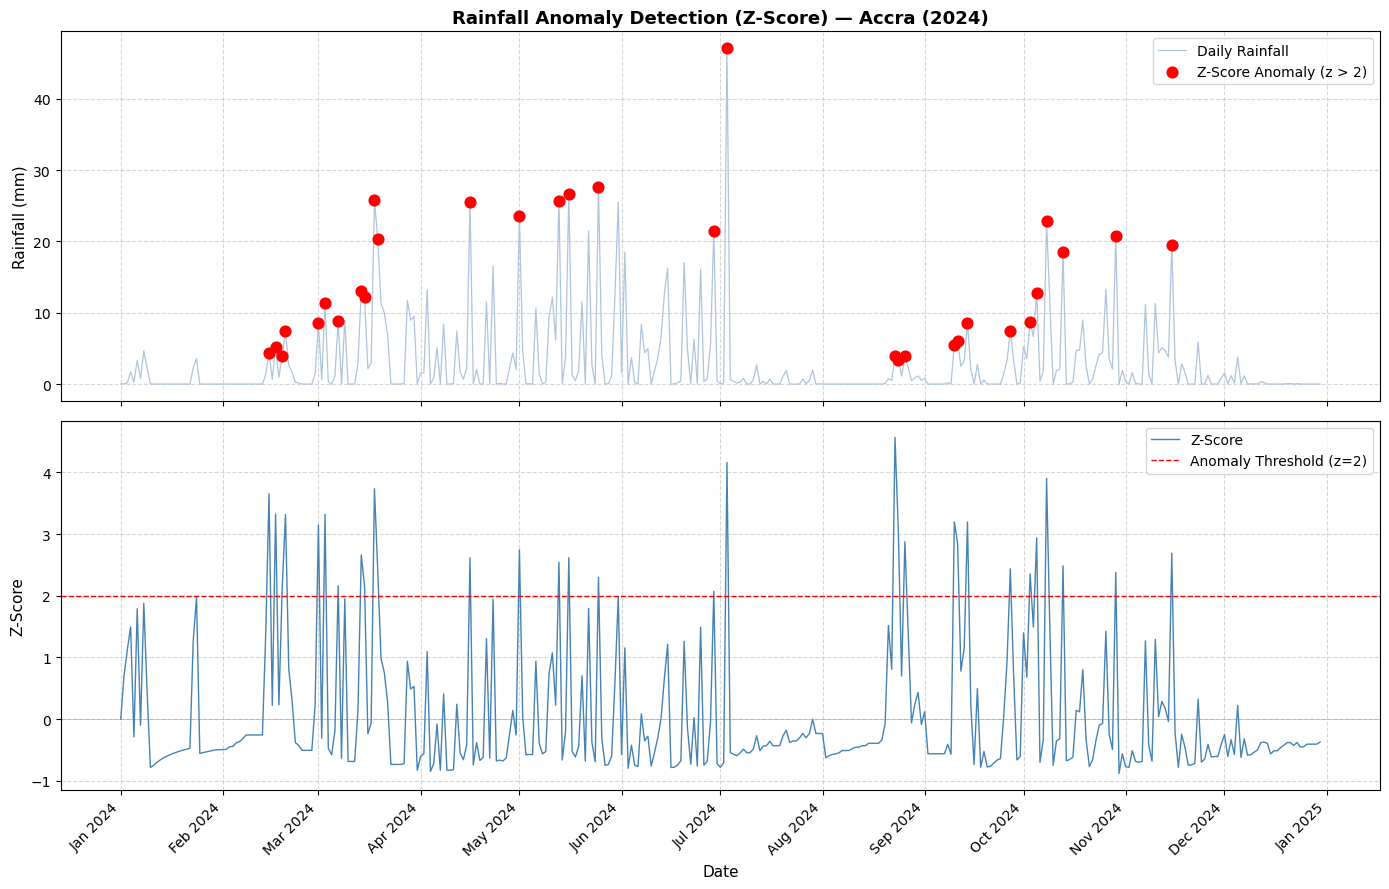

In [11]:
#Anomaly Detection & Wet Spell Analysis (Phase 2 Prep)
import numpy as np

# ── Z-Score Anomaly Detection ─────────────────────────────────────────
df_fe = df.copy().set_index("date").sort_index()

df_fe["roll_7d"]    = df_fe["precipitation"].rolling(7,  min_periods=1).mean()
df_fe["roll_30d"]   = df_fe["precipitation"].rolling(30, min_periods=1).mean()
df_fe["cumulative"] = df_fe["precipitation"].cumsum()
df_fe["rainfall_class"] = df_fe["precipitation"].apply(classify_rainfall)

# Z-score on 30-day rolling window
rolling_mean = df_fe["precipitation"].rolling(30, min_periods=1).mean()
rolling_std  = df_fe["precipitation"].rolling(30, min_periods=1).std().fillna(1)
df_fe["z_score"] = (df_fe["precipitation"] - rolling_mean) / rolling_std

# Flag statistical anomalies (z > 2)
df_fe["is_anomaly"] = df_fe["z_score"] > 2.0

# ── Wet Spell Detection ───────────────────────────────────────────────
# A wet spell = 3+ consecutive days with precipitation > 1 mm
df_fe["is_wet"]        = df_fe["precipitation"] > 1.0
df_fe["wet_spell_id"]  = (
    df_fe["is_wet"]
    .ne(df_fe["is_wet"].shift())
    .cumsum()
)
wet_spells = (
    df_fe[df_fe["is_wet"]]
    .groupby("wet_spell_id")
    .filter(lambda x: len(x) >= 3)
)

print(f"\n🔵 Statistical anomaly days (z > 2.0): {df_fe['is_anomaly'].sum()}")
print(f"🌧️  Wet spell days (≥3 consecutive wet days): {len(wet_spells)}")

# ── Plot: Z-Score Anomaly Detection ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: Rainfall + anomalies
axes[0].plot(df_fe.index, df_fe["precipitation"],
             color="lightsteelblue", linewidth=0.9, label="Daily Rainfall")
axes[0].scatter(
    df_fe[df_fe["is_anomaly"]].index,
    df_fe[df_fe["is_anomaly"]]["precipitation"],
    color="red", s=60, zorder=5, label="Z-Score Anomaly (z > 2)"
)
axes[0].set_title("Rainfall Anomaly Detection (Z-Score) — Accra (2024)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rainfall (mm)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Bottom: Z-score series
axes[1].plot(df_fe.index, df_fe["z_score"],
             color="steelblue", linewidth=1.0, label="Z-Score")
axes[1].axhline(y=2.0, color="red", linestyle="--",
                linewidth=1.0, label="Anomaly Threshold (z=2)")
axes[1].axhline(y=0,   color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
axes[1].set_ylabel("Z-Score", fontsize=11)
axes[1].set_xlabel("Date",    fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

import matplotlib.dates as mdates
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../data/processed/accra_zscore_anomaly_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()


── Top 10 Flood-Risk Days ──
            precipitation    roll_3d   z_score  flood_risk_score   risk_tier
date                                                                        
2024-07-03      47.084717  47.258280  4.158660             92.57  🔴 Critical
2024-05-13      25.715242  44.086536  2.541663             81.18  🔴 Critical
2024-03-18      25.803489  30.893589  3.734913             77.43  🔴 Critical
2024-03-19      20.400253  49.152970  2.415913             76.01  🔴 Critical
2024-05-16      26.611757  30.426568  2.615450             75.03  🔴 Critical
2024-05-25      27.655854  30.318554  2.299554             73.72      🟠 High
2024-05-31      25.490120  39.123158  1.985710             73.36      🟠 High
2024-04-16      25.549006  28.483594  2.613719             72.46      🟠 High
2024-05-01      23.557323  29.934299  2.743257             71.73      🟠 High
2024-10-08      22.786453  24.960523  3.901646             69.94      🟠 High


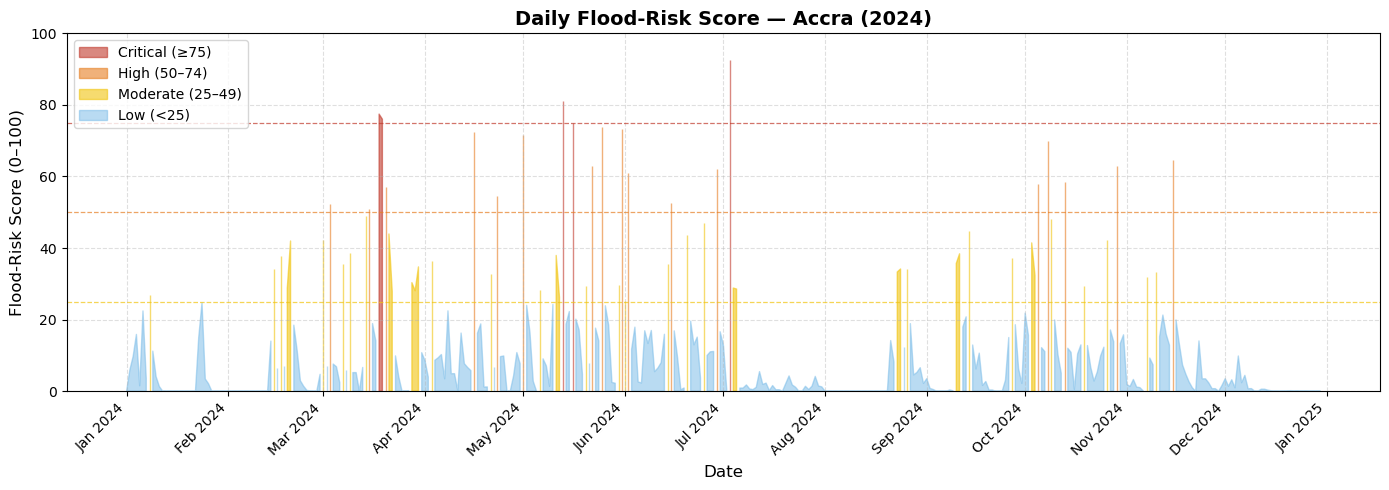

In [12]:
#Flood-Risk Scoring
# ── Flood-Risk Score (0–100) ──────────────────────────────────────────
# Composite score from: daily rainfall + 3-day accumulation + z-score

df_fe["roll_3d"] = df_fe["precipitation"].rolling(3, min_periods=1).sum()

def flood_risk_score(row):
    score = 0
    # Daily rainfall component (max 40 pts)
    score += min(row["precipitation"] / 30 * 40, 40)
    # 3-day accumulation component (max 35 pts)
    score += min(row["roll_3d"] / 60 * 35, 35)
    # Z-score component (max 25 pts)
    score += min(max(row["z_score"], 0) / 3 * 25, 25)
    return round(score, 2)

df_fe["flood_risk_score"] = df_fe.apply(flood_risk_score, axis=1)

# Risk tier labels
def risk_tier(score):
    if score >= 75: return "🔴 Critical"
    elif score >= 50: return "🟠 High"
    elif score >= 25: return "🟡 Moderate"
    return "🟢 Low"

df_fe["risk_tier"] = df_fe["flood_risk_score"].apply(risk_tier)

# Top high-risk days
top_risk = df_fe.nlargest(10, "flood_risk_score")[
    ["precipitation", "roll_3d", "z_score", "flood_risk_score", "risk_tier"]
]
print("\n── Top 10 Flood-Risk Days ──")
print(top_risk.to_string())

# ── Plot: Flood-Risk Score Timeline ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_fe.index, df_fe["flood_risk_score"],
                where=df_fe["flood_risk_score"] >= 75,
                color="#c0392b", alpha=0.6, label="Critical (≥75)")
ax.fill_between(df_fe.index, df_fe["flood_risk_score"],
                where=(df_fe["flood_risk_score"] >= 50) &
                      (df_fe["flood_risk_score"] < 75),
                color="#e67e22", alpha=0.6, label="High (50–74)")
ax.fill_between(df_fe.index, df_fe["flood_risk_score"],
                where=(df_fe["flood_risk_score"] >= 25) &
                      (df_fe["flood_risk_score"] < 50),
                color="#f1c40f", alpha=0.6, label="Moderate (25–49)")
ax.fill_between(df_fe.index, df_fe["flood_risk_score"],
                where=df_fe["flood_risk_score"] < 25,
                color="#74b9e7", alpha=0.5, label="Low (<25)")

ax.axhline(y=75, color="#c0392b", linestyle="--", linewidth=0.9, alpha=0.7)
ax.axhline(y=50, color="#e67e22", linestyle="--", linewidth=0.9, alpha=0.7)
ax.axhline(y=25, color="#f1c40f", linestyle="--", linewidth=0.9, alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Daily Flood-Risk Score — Accra (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Flood-Risk Score (0–100)", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../data/processed/accra_flood_risk_score_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
#Save Feature DataFrame to Parquet
# ── Save Feature-Engineered DataFrame ────────────────────────────────
output_path = "../data/processed/accra_features_2024.parquet"

df_fe.to_parquet(output_path)

print(f"✅ Feature dataframe saved → {output_path}")
print(f"   Shape  : {df_fe.shape[0]} rows × {df_fe.shape[1]} columns")
print(f"   Columns: {list(df_fe.columns)}")


✅ Feature dataframe saved → ../data/processed/accra_features_2024.parquet
   Shape  : 365 rows × 12 columns
   Columns: ['precipitation', 'rainfall_class', 'roll_7d', 'roll_30d', 'cumulative', 'z_score', 'is_anomaly', 'is_wet', 'wet_spell_id', 'roll_3d', 'flood_risk_score', 'risk_tier']
